In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

Import Dataset

In [2]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])
train_data=datasets.CIFAR10(root='./data',train=True,download=True,transform=transform)
test_data=datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)

train_loader=DataLoader(train_data,batch_size=128,shuffle=True)
test_loader=DataLoader(test_data,batch_size=128)

100%|██████████| 170M/170M [00:03<00:00, 43.9MB/s]


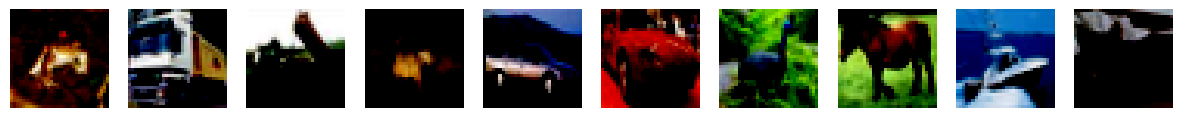

In [3]:
plt.figure(figsize=(15, 3))
for i in range(10):
  plt.subplot(1, 10, i + 1) # 1 row, 10 columns, current image index
  # Reorder dimensions from (C, H, W) to (H, W, C) for imshow
  plt.imshow(train_data[i][0].permute(1, 2, 0).numpy())
  plt.axis('off')
plt.show()

AlexNET architecture

In [16]:
from torch.nn.modules.batchnorm import BatchNorm1d
class AlexNET(nn.Module):
  def __init__(self,num_classes=10):
    super().__init__()
    self.features=nn.Sequential(
        #Conv1
        nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),

        #Conv2
        nn.Conv2d(in_channels=64,out_channels=192,kernel_size=3,padding=1),
        nn.BatchNorm2d(192),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),

        #Conv3
        nn.Conv2d(in_channels=192,out_channels=384,kernel_size=3,padding=1),
        nn.BatchNorm2d(384),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),

        #conv4
        nn.Conv2d(in_channels=384,out_channels=256,kernel_size=3,padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),

        #conv5
        nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2)
        )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=256*1*1,out_features=256),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(in_features=256,out_features=256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),

        nn.Linear(in_features=256,out_features=num_classes)
    )

  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x

In [17]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=AlexNET().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

Testing and Traning Loop

In [24]:
EPOCHS=10
for epoch in range(EPOCHS):
  model.train()
  total_loss=0
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"The total loss for epoch: {epoch+1} is {total_loss:.3f}")

The total loss for epoch: 1 is 546.639
The total loss for epoch: 2 is 371.975
The total loss for epoch: 3 is 296.126
The total loss for epoch: 4 is 244.342
The total loss for epoch: 5 is 203.778
The total loss for epoch: 6 is 166.372
The total loss for epoch: 7 is 138.343
The total loss for epoch: 8 is 110.424
The total loss for epoch: 9 is 88.377
The total loss for epoch: 10 is 74.716


In [25]:
model.eval()
correct=0
total=0
with torch.no_grad():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
  print(f"The accuracy is : {100* correct/total:.2f}%")

The accuracy is : 77.79%
